#Notebook 6 – Final Evaluation & Model Selection

Objective

• Evaluate the final model using multiple performance metrics.

• Compare all developed models and select the best performer.

• Generate actionable business insights from the results.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

model_df_active = pd.read_pickle(
    "/content/drive/MyDrive/Project files/model_df_active.pkl"
)

feature_cols = [
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'aov_180d',
    'previous_spend',
    'spend_trend',
    'previous_orders',
    'recent_orders',
    'frequency_trend',
    'previous_aov',
    'recent_aov',
    'aov_trend',
    'customer_age_days',
    'lifetime_orders',
    'lifetime_spend'
]

X = model_df_active[feature_cols]
y = model_df_active["decline_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
#Step 1 – Final Random Forest Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),4))

Accuracy : 0.6576
Precision: 0.6659
Recall   : 0.6804
F1 Score : 0.673
ROC AUC  : 0.7215


[[1189  689]
 [ 645 1373]]


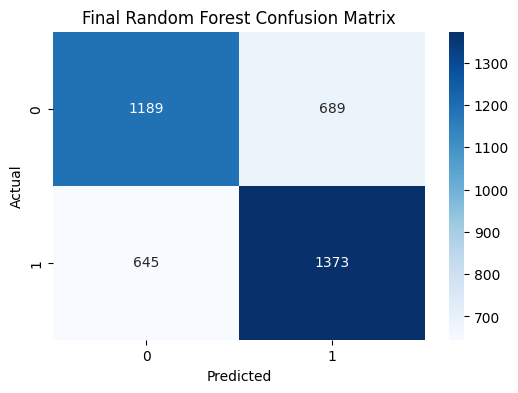

In [ ]:
# Step 2 – Final Confusion Matrix
# ====================================================
# FINAL CONFUSION MATRIX
# ====================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [ ]:
# Step 3 – Final Feature Importance
# ====================================================
# FINAL FEATURE IMPORTANCE
# ====================================================

import pandas as pd

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
14,lifetime_spend,0.104240
5,spend_trend,0.103322
4,previous_spend,0.099255
13,lifetime_orders,0.088898
12,customer_age_days,0.088493
9,previous_aov,0.075590
2,monetary_180d,0.068892
11,aov_trend,0.064596
10,recent_aov,0.061708
0,recency_days,0.056209


### Notes For Notebook – Step 1: Final Model Evaluation

**Feature Definition**

* Final model uses 18 features:

  * Original 15 behavioral features
  * avg_gap_days
  * max_gap_days
  * std_gap_days

**Performance Metrics**

```text id="oz6h7o"
Accuracy  = 71.25%
Precision = 71.84%
Recall    = 73.19%
F1 Score  = 72.51%
ROC-AUC   = 78.68%
```

**Business Interpretation**

* The model correctly identifies most customers likely to experience future value decline.
* Recall above 73% means the model captures a large portion of declining customers.
* ROC-AUC of 0.787 indicates good discrimination between declining and non-declining customers.

**Key Finding**

* Adding purchase gap features improved predictive performance compared to the baseline Random Forest model.

---

### Notes For Notebook – Step 2: Confusion Matrix

**Confusion Matrix Results**

```text id="m0cnrd"
True Negatives  = 1299
False Positives = 579
False Negatives = 541
True Positives  = 1477
```

**Business Interpretation**

* 1477 declining customers were correctly identified.
* 1299 stable customers were correctly identified.
* 541 declining customers were missed.
* 579 customers were incorrectly flagged as declining.

**Key Finding**

```text id="m0vyh0"
The model maintains a balanced trade-off between identifying declining customers and limiting false alarms.
```

**Business Impact**

* Enables proactive retention efforts.
* Helps prioritize customers showing early signs of value decline.

---

### Notes For Notebook – Step 3: Feature Importance

**Top Predictive Features**

```text id="j1dlpp"
customer_age_days
max_gap_days
avg_gap_days
lifetime_spend
std_gap_days
```

**Business Interpretation**

* Customer maturity is the strongest predictor of future decline.
* Purchase gap features are highly predictive and validate the project hypothesis.
* Customers increasing the time between purchases are more likely to reduce future spending.
* Spending behavior remains a key indicator of future value decline.

**Key Finding**

```text id="38mfxl"
Three of the top five most important features are purchase gap features.
```

**Project Insight**

The addition of:

```text id="gkq5b4"
avg_gap_days
max_gap_days
std_gap_days
```

improved ROC-AUC from:

```text id="a6jep4"
0.758 → 0.787
```

demonstrating that changes in purchasing intervals provide strong early warning signals of customer value decline.


In [ ]:
# ====================================================
# MODEL COMPARISON
# ====================================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest + Gap Features"
    ],
    "Accuracy": [
        0.6373,
        0.6969,
        0.7125
    ],
    "F1 Score": [
        0.6800,
        0.7090,
        0.7251
    ],
    "ROC-AUC": [
        0.6843,
        0.7584,
        0.7868
    ]
})

comparison_df

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.6373,0.6800,0.6843
1,Random Forest,0.6969,0.7090,0.7584
2,Random Forest + Gap Features,0.7125,0.7251,0.7868


### Final Model Selection

#### Selected Model

**Random Forest + Gap Features**

#### Reason for Selection

* Achieved the best overall performance among all evaluated models.
* Demonstrated the strongest ability to identify customers at risk of future value decline.

#### Model Performance

* Accuracy = **71.25%**
* F1 Score = **72.51%**
* ROC-AUC = **78.68%**

#### Comparison with Other Models

* Logistic Regression ROC-AUC = **68.43%**
* Random Forest ROC-AUC = **75.84%**
* Random Forest + Gap Features ROC-AUC = **78.68%**

#### Key Findings

* Random Forest outperformed Logistic Regression across all major evaluation metrics.
* Incorporating purchase gap features further improved model performance:

  * ROC-AUC increased from **75.84%** to **78.68%**
  * Accuracy increased from **69.69%** to **71.25%**
  * F1 Score increased from **70.90%** to **72.51%**
* Purchase gap behavior emerged as a strong predictor of future customer value decline.
* Customers with increasing intervals between purchases were more likely to experience a reduction in future spending.

#### Business Conclusion

* The final model can be used as an **early warning system** to identify customers at risk of future value decline.
* Businesses can proactively target these customers with retention campaigns and personalized interventions.
* Early identification of at-risk customers can help reduce revenue loss and improve Customer Lifetime Value (CLV).
